# **Grupo JKL**

## **Global Solution - 1º Semestre - 2ESR**

|             Nome Completo             |   RM   |
|---------------------------------------|--------|
|João Gabriel Boaventura Marques e Silva|RM569298|
|Kauai Rosa de Assis Rocha              |RM561344|
|Leandro Afonso Silva Santos Junior     |RM563256|


---

# **1. Contextualização**

### Tema: Incêndios florestais

As queimadas representam um dos principais problemas ambientais da atualidade, causando impactos na biodiversidade, no clima e na qualidade do ar.

O monitoramento ambiental realizado por satélites permite identificar áreas queimadas, padrões de ocorrência e regiões mais afetadas, auxiliando órgãos ambientais na tomada de decisões estratégicas.

A economia espacial está diretamente relacionada ao uso de tecnologias orbitais e sensoriamento remoto para coleta e análise de dados ambientais.

O objetivo deste projeto é aplicar técnicas de Estatística Descritiva em dados reais de áreas queimadas em Unidades de Conservação Federais, buscando identificar padrões, dispersões, outliers e tendências relevantes.

# **2. Preparação dos dados**

In [ ]:
# @title **Carregando o arquivo**
import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

caminho = kagglehub.dataset_download("dandamb/reas-queimadas-em-ucs-federais")
diretorio = os.listdir(caminho)

for d in diretorio:
  if d.endswith('.csv'): csv = d; break

if csv: arquivo = os.path.join(caminho, csv)

df = pd.read_csv(arquivo, sep=";")
df.head()

100%|██████████| 7.21k/7.21k [00:00<00:00, 18.2MB/s]

Extracting files...


,UC,AREA,ANO
0,APA Carste de Lagoa Santa,"162,89",2023
1,APA Cavernas do Peruaçu,"260,65",2017
2,APA Cavernas do Peruaçu,"123,91",2019
3,APA Cavernas do Peruaçu,"85,95",2020
4,APA Cavernas do Peruaçu,"640,73",2022


In [ ]:
# @title **Visualização dos Dados**

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 771 entries, 0 to 770
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   UC      771 non-null    object
 1   AREA    771 non-null    object
 2   ANO     771 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 18.2+ KB


,ANO
count,771.000000
mean,2017.926070
std,4.195976
min,2007.000000
25%,2015.000000
50%,2018.000000
75%,2022.000000
max,2023.000000


In [ ]:
# @title **Padronizando o nome das colunas**
df.columns = df.columns.str.lower()
df.columns

Index(['uc', 'area', 'ano'], dtype='object')

In [ ]:
# @title **Transformando os valores da coluna `area` em float**
df['area'] = (df['area'].str.replace(',', '.').astype(float))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 771 entries, 0 to 770
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   uc      771 non-null    object 
 1   area    771 non-null    float64
 2   ano     771 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 18.2+ KB


In [ ]:
# @title **Removendo duplicatas e nulos**
df.drop_duplicates(inplace=True)
print("Quantidade de duplicatas:", df.duplicated().sum())

df.dropna(inplace=True)
print("Valores nulos por coluna: ", df.isnull().sum())

Quantidade de duplicatas: 0
Valores nulos por coluna:  uc      0
area    0
ano     0
dtype: int64


---

# **3. ESTATÍSTICA DESCRITIVA**

In [ ]:
# @title **Medidas de Tendência Central e Dispersão**

media = round(df['area'].mean(), 2)
mediana = round(df['area'].median(), 2)
moda = df['area'].mode()[0]
amplitude = round((df['area'].max() - df['area'].min()),2)
variancia = round(df['area'].var(), 2)
desvio_padrao = round(df['area'].std(), 2)
coeficiente_variacao = round((desvio_padrao / media) * 100, 2)


print('Média:', media)
print('Mediana:', mediana)
print('Moda:', moda)
print('Amplitude:', amplitude)
print('Variância:', variancia)
print('Desvio padrão:', desvio_padrao)
print('Coeficiente de variação:',coeficiente_variacao)

Média: 21406.73
Mediana: 1858.75
Moda: 0.85
Amplitude: 370465.32
Variância: 2842005848.28
Desvio padrão: 53310.47
Coeficiente de variação: 249.04


In [ ]:
# @title **Medidas posicionais**
q1 = df['area'].quantile(0.25)
q2 = df['area'].quantile(0.50)
q3 = df['area'].quantile(0.75)

p10 = df['area'].quantile(0.10)
p90 = df['area'].quantile(0.90)

print('Primeiro Quartil:', q1)
print('Segundo Quartil:', q2)
print('Terceiro Quartil:', q3)
print('Percentil 10%:', p10)
print('Percentil 90%:', p90)

Primeiro Quartil: 321.68
Segundo Quartil: 1858.75
Terceiro Quartil: 13739.36
Percentil 10%: 69.55
Percentil 90%: 53291.31


In [ ]:
#@title **Outliers com IQR**
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = df[(df['area'] > limite_superior)]
display(outliers)

percentual = (len(outliers) / len(df)) * 100
print(f"Outliers: {len(outliers)} eventos ({percentual:.2f}%)")

,uc,area,ano
52,APA dos Meandros do Rio Araguaia,119319.47,2007
53,APA dos Meandros do Rio Araguaia,151619.37,2010
54,APA dos Meandros do Rio Araguaia,82626.45,2012
55,APA Meandros do Rio Araguaia,114142.61,2017
56,APA Meandros do Rio Araguaia,35269.48,2022
...,...,...,...
644,REBIO do Guaporé,47233.72,2020
751,REVIS das Veredas do Oeste Baiano,49071.50,2014
754,REVIS das Veredas do Oeste Baiano,39767.39,2017
756,REVIS das Veredas do Oeste Baiano,52223.35,2021


Outliers: 118 eventos (15.30%)


In [ ]:
# @title **Colocando o valores em um dataset**
estatisticas = pd.DataFrame({
    'Medida': ['Média', 'Mediana', 'Moda', 'Amplitude',
               'Variância', 'Desvio Padrão', 'Coeficiente de Variação',
               'Primeiro Quartil', 'Segundo Quartil', 'Terceiro Quartil',
               'Percentil 10%', 'Percentil 90%', 'IQR', 'Limite Inferior', 'Limite Superior'],

    'Valor': [media, mediana, moda, amplitude,
              variancia, desvio_padrao, coeficiente_variacao,
              q1, q2, q3, p10, p90, iqr, limite_inferior, limite_superior]
})
estatisticas['Valor'] = estatisticas['Valor'].apply(lambda x: f'{x:,.2f}')
display(estatisticas)

,Medida,Valor
0,Média,"21,406.73"
1,Mediana,"1,858.75"
2,Moda,0.85
3,Amplitude,"370,465.32"
4,Variância,"2,842,005,848.28"
5,Desvio Padrão,"53,310.47"
6,Coeficiente de Variação,249.04
7,Primeiro Quartil,321.68
8,Segundo Quartil,"1,858.75"
9,Terceiro Quartil,"13,739.36"


---

# **4. Análise de Distribuição**

In [ ]:
assimetria = stats.skew(df['area'])
curtose = stats.kurtosis(df['area'])
estatistica, pValor = stats.normaltest(df['area'])

print(f"Assimetria: {assimetria:.2f}")
print(f"Curtose: {curtose:.2f}")
print(f"Estatística: {estatistica:.2f}")
print(f"p-valor: {pValor}")
if pValor < 0.05:
    print("Distribuição não normal")
else:
    print("Distribuição normal")

Assimetria: 3.80
Curtose: 15.35
Estatística: 628.60
p-valor: 3.173347652806046e-137
Distribuição não normal


In [ ]:
print(f'Quantidade de outliers: {len(outliers)}')
outliers.sort_values( by='area', ascending=False).head(10)

Quantidade de outliers: 118


,uc,area,ano
484,PARNA do Araguaia,370465.32,2017
128,ESEC Serra Geral do Tocantins,349863.80,2007
475,PARNA do Araguaia,341764.05,2007
486,PARNA do Araguaia,329410.25,2019
483,PARNA do Araguaia,305337.96,2016
129,ESEC Serra Geral do Tocantins,303965.28,2010
140,ESEC Serra Geral do Tocantins,297816.73,2022
132,ESEC Serra Geral do Tocantins,286303.73,2014
479,PARNA do Araguaia,277808.38,2012
477,PARNA do Araguaia,277560.28,2010


# Interpretação da Distribuição

**Assimetria positiva (3.80):** a maioria dos eventos de queimada concentra-se em áreas pequenas, com poucos eventos de área muito grande.

**Curtose elevada (15.35):** distribuição leptocúrtica - confirmando a presença de outliers extremos com impacto real nos dados.

**Teste de normalidade (p < 0.05):** a distribuição não segue padrão normal. A mediana é mais representativa que a média para descrever o comportamento típico dos eventos de queimada.

---

# **5. Visualizações(Gráficos)**

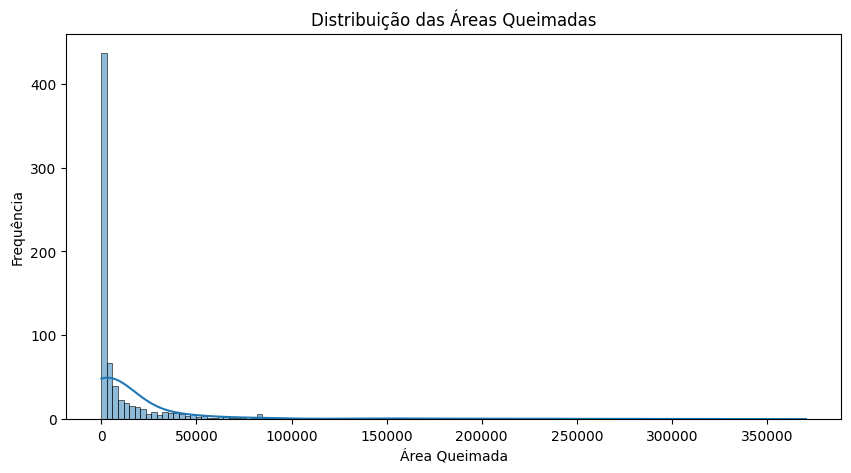

In [ ]:
#@title **Histograma**

plt.figure(figsize=(10,5))

sns.histplot(df['area'], kde=True)
plt.title('Distribuição das Áreas Queimadas')
plt.xlabel('Área Queimada')
plt.ylabel('Frequência')

plt.show()

## Interpretação - Histograma

O histograma evidencia forte concentração dos eventos na faixa de 0 a 10.000 hectares, com frequência superior a 430 ocorrências nesse intervalo. A partir daí, a frequência cai abruptamente e se mantém próxima de zero ao longo de toda a cauda direita, que se estende até aproximadamente 380.000 hectares.

A curva KDE reforça a assimetria positiva: a distribuição não é simétrica nem normal. A maior parte dos incêndios em Unidades de Conservação Federais atinge áreas relativamente pequenas, enquanto eventos de grande escala são raros, porém existentes e estatisticamente relevantes como outliers.

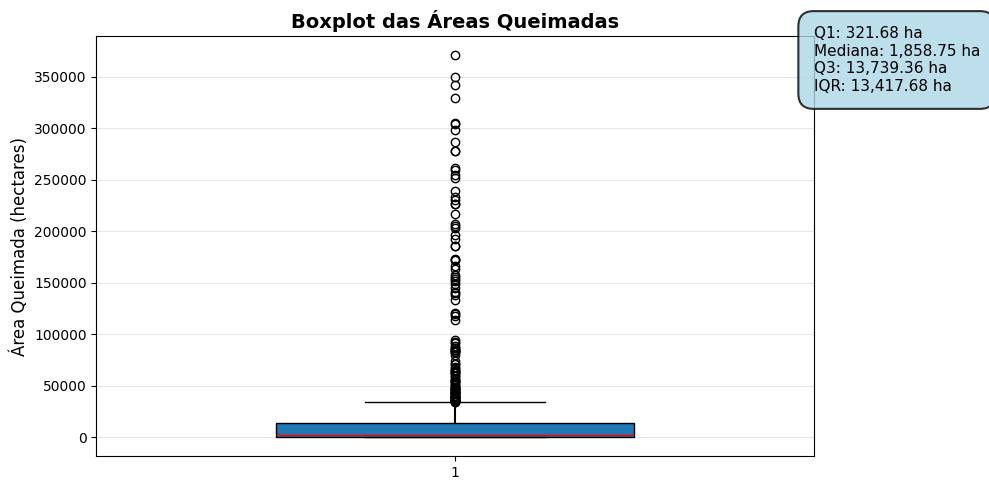

In [ ]:
#@title **Boxplot**
plt.figure(figsize=(10, 5))

box = plt.boxplot(df['area'],
                  patch_artist=True,
                  widths=0.5,
                  whiskerprops=dict(linewidth=1.5),
                  medianprops=dict(color='red', linewidth=1))

plt.title('Boxplot das Áreas Queimadas', fontsize=14, fontweight='bold')
plt.ylabel('Área Queimada (hectares)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

stats_text = f'''Q1: {q1:,.2f} ha
Mediana: {q2:,.2f} ha
Q3: {q3:,.2f} ha
IQR: {iqr:,.2f} ha'''

plt.text(1.5, df['area'].max() * 0.9, stats_text,
         fontsize=11,
         bbox=dict(boxstyle='round,pad=1', facecolor='lightblue', alpha=0.8,
                   linewidth=1.5), verticalalignment='bottom')

plt.tight_layout()
plt.show()

## Interpretação - Boxplot

O boxplot concentra 50% central dos eventos entre Q1 (321,68 ha) e Q3 (13.739,36 ha), com mediana de 1.858,75 ha.

O IQR de 13.417,68 ha define o limite superior em aproximadamente 33.865 ha. Acima desse valor, a nuvem de pontos isolados revela dezenas de outliers, com eventos chegando a 370.000 ha.

A caixa comprimida na base do gráfico frente à extensão da cauda superior sintetiza visualmente o padrão do dado: eventos pequenos são a norma, eventos extremos são a exceção com consequências desproporcionais.

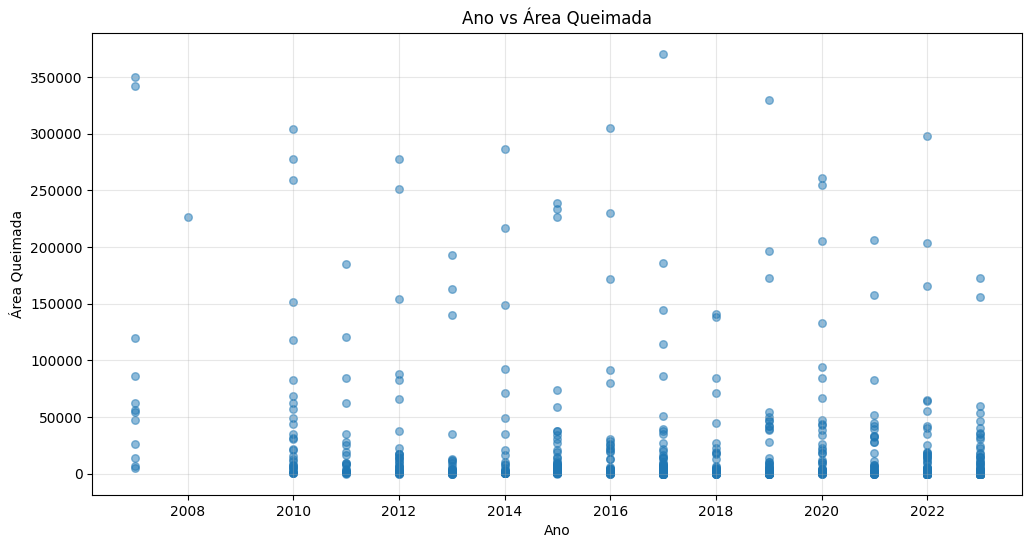

In [ ]:
#@title **Scatterplot**

plt.figure(figsize=(12,6))
plt.scatter(df['ano'], df['area'], alpha=0.5, s=30)
plt.title('Ano vs Área Queimada')
plt.xlabel('Ano')
plt.ylabel('Área Queimada')
plt.grid(True, alpha=0.3)
plt.show()

## Interpretação - Scatterplot

O gráfico revela que eventos de grande escala (acima de 150.000 ha) ocorrem de forma dispersa ao longo de toda a série histórica (2007–2023), sem tendência linear clara de aumento ou redução. Isso indica que a magnitude dos incêndios está mais associada a condições climáticas e de gestão específicas de cada ano do que a uma trajetória temporal consistente.

Pontos de destaque: 2017 registra o maior evento isolado (~ 370.000 ha), seguido por 2007 (~ 350.000 ha) e 2010 (~ 305.000 ha). A densidade de pontos próximos a zero é constante em todos os anos, confirmando que a maioria dos eventos permanece em área reduzida independentemente do período.

Não há correlação temporal evidente entre ano e área queimada — dado corroborado pelo heatmap de correlação.

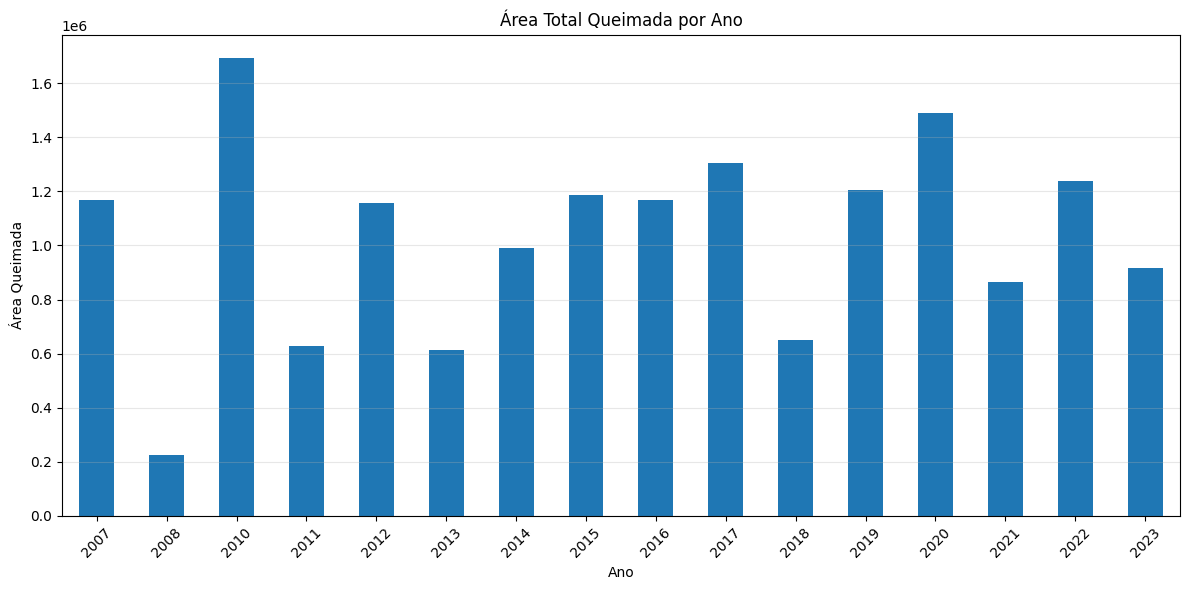

In [ ]:
queimadas_por_ano = df.groupby('ano')['area'].sum().sort_index()
queimadas_por_ano.plot(kind='bar', figsize=(12,6))
plt.title('Área Total Queimada por Ano')
plt.xlabel('Ano')
plt.ylabel('Área Queimada')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Interpretação - Gráfico de Barras

2010 é o ano crítico da série, com área total próxima a 1,7 milhão de hectares  - valor aproximadamente 7,5x superior ao de 2008 (menor registro, ~226.000 ha). Esse contraste extremo evidencia que a crise de queimadas não é linear nem contínua, mas episódica.

Anos com totais elevados (acima de 1,1 milhão de ha): 2007, 2010, 2012, 2015, 2016, 2017, 2019, 2020 e 2022. A recorrência desses picos em múltiplos anos indica que o problema não foi contido estruturalmente ao longo do período analisado.

2011, 2013, 2018 e 2021 funcionam como anos de menor impacto relativo, possivelmente associados a condições climáticas mais favoráveis ou maior efetividade de ações de prevenção — hipótese que exigiria dados externos para confirmação.

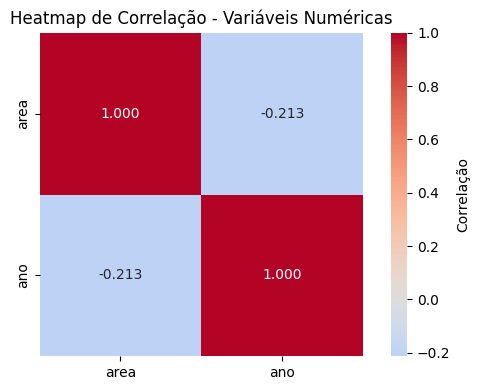

In [ ]:
df_numeric = df[['area', 'ano']].copy()
corr_matrix = df_numeric.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, cbar_kws={'label': 'Correlação'})
plt.title('Heatmap de Correlação - Variáveis Numéricas')
plt.tight_layout()
plt.show()

## Interpretação - Heatmap de Correlação

A correlação próxima de zero confirma o que o scatterplot já sugeria: o ano por si só não é um preditor relevante da área queimada. Fatores não presentes no dataset — como precipitação, temperatura, bioma e pressão antrópica — têm peso determinante nos eventos de grande escala.

---
# 6. **Perguntas de negócio**

### *1. Quais Unidades de Conservação apresentaram as maiores áreas queimadas?*

PARNA do Araguaia liderou com maior área acumulada, seguido por ESEC Serra Geral do Tocantins e PARNA das Nascentes do Rio Parnaíba. Concentração em poucas regiões indica vulnerabilidade geográfica específica.

In [ ]:
# Ranking de UCs por área total queimada
ranking_ucs = df.groupby('uc')['area'].sum().sort_values(ascending=False)
total_geral = ranking_ucs.sum()

ranking_df = pd.DataFrame({
    'Area Total (ha)': ranking_ucs,
    'Percentual (%)': (ranking_ucs / total_geral * 100).round(2)
})

display(ranking_df.head(10))
print(f"\nTop 3 UCs concentram {ranking_df['Percentual (%)'].head(3).sum():.2f}% do total queimado")

,Area Total (ha),Percentual (%)
uc,,
PARNA do Araguaia,3766751.51,22.82
ESEC Serra Geral do Tocantins,3346521.50,20.28
PARNA das Nascentes do Rio Parnaíba,2265827.83,13.73
PARNA da Serra da Canastra,871884.39,5.28
ESEC de Uruçuí-Una,559765.82,3.39
PARNA da Chapada dos Veadeiros,448412.22,2.72
PARNA da Chapada das Mesas,402883.32,2.44
FLONA do Jamanxim,382953.32,2.32
PARNA das Emas,364954.66,2.21



Top 3 UCs concentram 56.83% do total queimado


---

### *2. Existem anos com ocorrência significativamente maior de queimadas?*

Sim. 2010 registrou 1.693.950,68 ha, contra 226.151,60 ha em 2008. Variação de ~7.5x indica períodos críticos associados a condições climáticas extremas.

---

### *3. Os dados apresentam valores extremos relevantes?*

Sim. Boxplot e histograma mostram múltiplos outliers acima de Q3 (13.739 ha). Representam eventos reais e foram mantidos na análise.

---

### *4. Como se comporta a distribuição das áreas queimadas?*

Assimetria positiva: maioria em áreas pequenas, poucos eventos extremos. Confirmado por histograma e boxplot.

---

### *5. Existe concentração das queimadas em determinadas Unidades de Conservação?*

Sim. Top 3 UCs concentram parcela significativa do total. Recomenda priorizar recursos de prevenção nessas regiões.

In [ ]:
ranking_acumulado = ranking_ucs.cumsum() / total_geral * 100
ucs_80 = (ranking_acumulado <= 80).sum() + 1
total_ucs = len(ranking_ucs)

print(f"Total de UCs no dataset: {total_ucs}")
print(f"UCs responsáveis por 80% da área queimada: {ucs_80} ({ucs_80/total_ucs*100:.1f}% das UCs)")
print(f"\nConcentração do Top 3:")
for uc, row in ranking_df.head(3).iterrows():
    print(f"  {uc}: {row['Area Total (ha)']:,.2f} ha ({row['Percentual (%)']:.2f}%)")

Total de UCs no dataset: 184
UCs responsáveis por 80% da área queimada: 12 (6.5% das UCs)

Concentração do Top 3:
  PARNA do Araguaia: 3,766,751.51 ha (22.82%)
  ESEC Serra Geral do Tocantins: 3,346,521.50 ha (20.28%)
  PARNA das Nascentes do Rio Parnaíba: 2,265,827.83 ha (13.73%)


---

# ***7. Conclusão Executiva***

**Principais Achados:** Concentração de queimadas em 3 UCs principais (PARNA Araguaia, ESEC Serra Geral, PARNA Nascentes Rio Parnaíba). Variabilidade temporal significativa com picos críticos. Distribuição assimétrica com eventos extremos.

**Aplicações Práticas:** Dados de satélites identificam áreas prioritárias para monitoramento e prevenção, apoiando decisões estratégicas em gestão ambiental.

**Limitações:** Análise restrita às variáveis disponíveis (uc, area, ano). Não contempla fatores climáticos, meteorológicos ou socioeconômicos.